# 04 — Credit Score Prediction

Evaluate the production credit-score regression model. The observed `credit_score` column is not used as an input feature for this model.

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd()
if not (ROOT / 'data').exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

print('Project root:', ROOT)

Project root: c:\Users\Dinesh more\OneDrive\Desktop\bank-loan-credit-risk-analysis\bank-loan-credit-risk-analysis


In [2]:
import json
import joblib
import pandas as pd
import numpy as np

from src.pipeline_utils import clean_common, feature_frame, CONFIG

models = {
    'loan_amount': joblib.load(ROOT/'models/loan_amount.joblib'),
    'loan_approval': joblib.load(ROOT/'models/loan_approval.joblib'),
    'credit_score': joblib.load(ROOT/'models/credit_score.joblib'),
    'credit_risk': joblib.load(ROOT/'models/credit_risk.joblib'),
}
print('Loaded:', ', '.join(models))

c:\Users\Dinesh more\anaconda3\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator SimpleImputer from version 1.8.0 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\Dinesh more\anaconda3\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.8.0 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\Dinesh more\anaconda3\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator Pipeline from version 1.8.0 when using version 1.7.2. This might lead 

Loaded: loan_amount, loan_approval, credit_score, credit_risk


c:\Users\Dinesh more\anaconda3\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator LabelEncoder from version 1.8.0 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

risk=clean_common(pd.read_csv(ROOT/'data/raw/credit_risk_data.csv'))
X=feature_frame(risk, CONFIG['features']['credit_score'])
y=risk.credit_score
_, X_test, _, y_test=train_test_split(X,y,test_size=.20,random_state=42)
pred=np.clip(models['credit_score'].predict(X_test),300,850)
print('MAE:',mean_absolute_error(y_test,pred))
print('RMSE:',mean_squared_error(y_test,pred)**0.5)
print('R2:',r2_score(y_test,pred))

MAE: 15.007433330990231
RMSE: 19.145374873593788
R2: 0.8620293057359676


In [4]:
comparison=pd.DataFrame({'actual_score':y_test,'predicted_score':pred})
comparison['absolute_error']=(comparison.actual_score-comparison.predicted_score).abs()
display(comparison.head(20))

,actual_score,predicted_score,absolute_error
1935,709,694.422611,14.577389
6494,674,675.317265,1.317265
1720,685,674.909386,10.090614
9120,599,617.968159,18.968159
360,688,699.756642,11.756642
9663,707,699.316826,7.683174
5277,648,665.996346,17.996346
8546,807,799.075102,7.924898
2221,673,673.061153,0.061153
4617,610,627.436084,17.436084


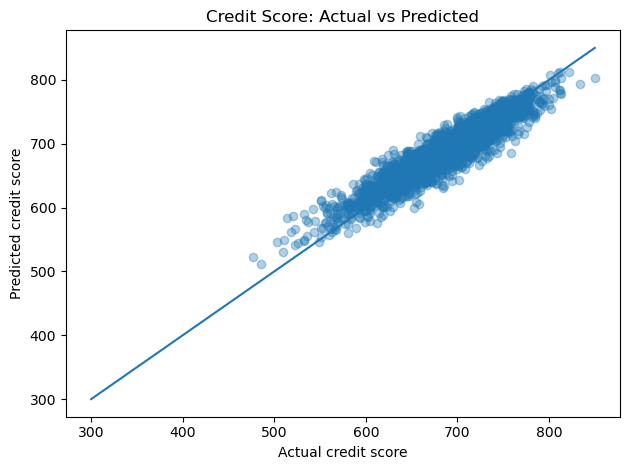

In [5]:
import matplotlib.pyplot as plt
plt.scatter(y_test,pred,alpha=.35)
plt.plot([300,850],[300,850])
plt.xlabel('Actual credit score'); plt.ylabel('Predicted credit score'); plt.title('Credit Score: Actual vs Predicted'); plt.tight_layout(); plt.show()

## Range guard
The application clips predictions to the standard 300–850 credit-score range.